In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/bhanupratapbiswas/superstore-sales/superstore_final_dataset (1).csv",
    encoding="latin1"
)

print(df.shape)
df.head()

(9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 9800
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null 

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 9800
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null 

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 9800


In [7]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    dayfirst=True
)

df['Ship_Date'] = pd.to_datetime(
    df['Ship_Date'],
    dayfirst=True
)

In [8]:
df[['Order_Date', 'Ship_Date']].head()

,Order_Date,Ship_Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [9]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()
df['Quarter'] = df['Order_Date'].dt.quarter

In [10]:
df['Shipping_Days'] = (
    df['Ship_Date'] - df['Order_Date']
).dt.days

In [11]:
df[['Order_Date', 'Ship_Date', 'Shipping_Days']].head()

,Order_Date,Ship_Date,Shipping_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [12]:
total_revenue = df['Sales'].sum()

total_orders = df['Order_ID'].nunique()

total_customers = df['Customer_ID'].nunique()

total_products = df['Product_ID'].nunique()

average_order_value = total_revenue / total_orders

average_shipping_days = df['Shipping_Days'].mean()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Average Order Value:", round(average_order_value, 2))
print("Average Shipping Days:", round(average_shipping_days, 2))

Total Revenue: 2261536.78
Total Orders: 4922
Total Customers: 793
Total Products: 1861
Average Order Value: 459.48
Average Shipping Days: 3.96


In [13]:
kpi = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Total Products',
        'Average Order Value',
        'Average Shipping Days'
    ],
    'Value': [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        average_order_value,
        average_shipping_days
    ]
})

kpi

,KPI,Value
0,Total Revenue,2.261537e+06
1,Total Orders,4.922000e+03
2,Total Customers,7.930000e+02
3,Total Products,1.861000e+03
4,Average Order Value,4.594752e+02
5,Average Shipping Days,3.961122e+00


   Year  Month      Sales       Date
0  2015      1  14205.707 2015-01-01
1  2015      2   4519.892 2015-02-01
2  2015      3  55205.797 2015-03-01
3  2015      4  27906.855 2015-04-01
4  2015      5  23644.303 2015-05-01


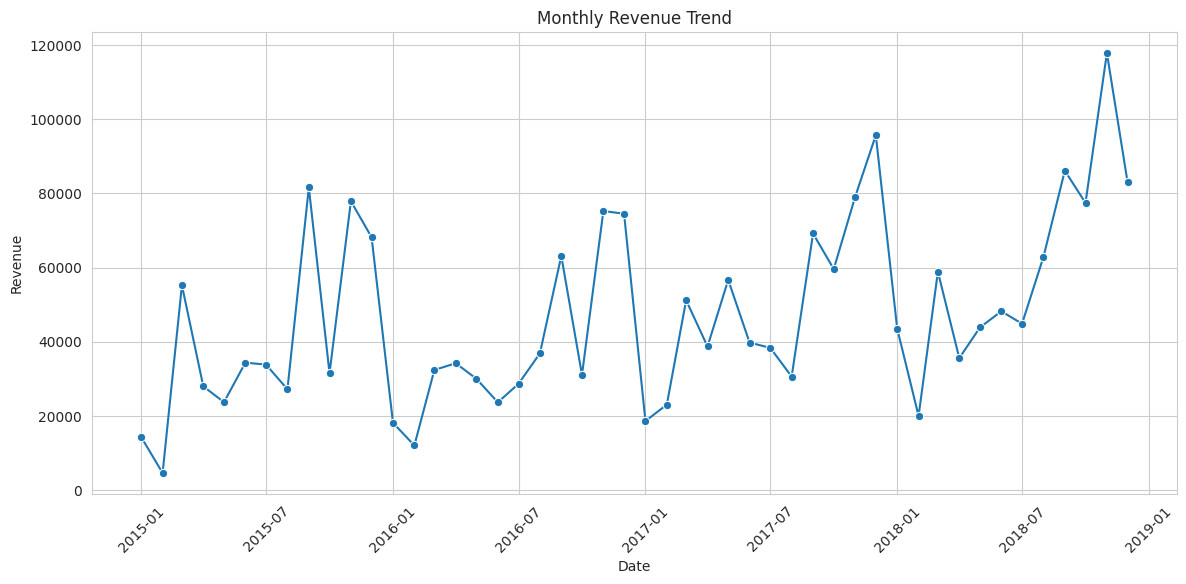

In [14]:
monthly_sales = df.groupby(
    ['Year', 'Month']
)['Sales'].sum().reset_index()

monthly_sales['Date'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' +
    monthly_sales['Month'].astype(str) + '-01'
)

monthly_sales = monthly_sales.sort_values('Date')

print(monthly_sales.head())

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x='Date',
    y='Sales',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

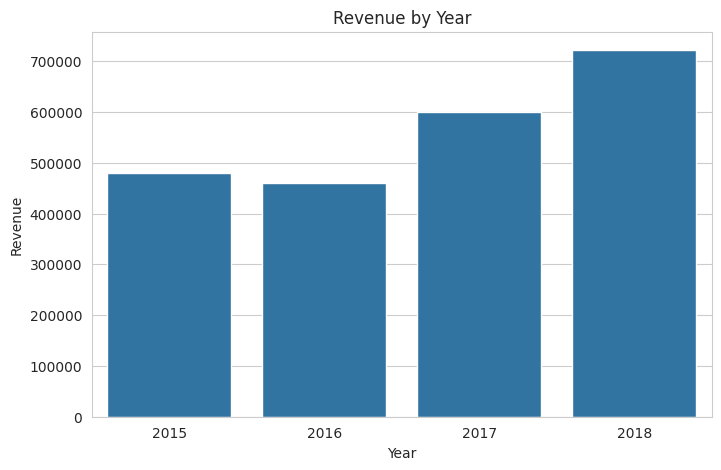

In [15]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title('Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')

plt.show()

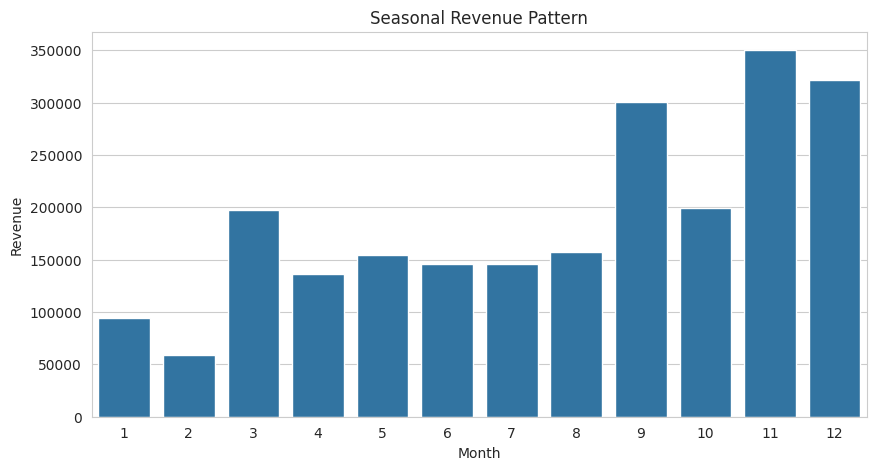

In [16]:
monthly_seasonality = df.groupby(
    'Month'
)['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_seasonality,
    x='Month',
    y='Sales'
)

plt.title('Seasonal Revenue Pattern')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [17]:
best_month = monthly_seasonality.loc[
    monthly_seasonality['Sales'].idxmax()
]

worst_month = monthly_seasonality.loc[
    monthly_seasonality['Sales'].idxmin()
]

print("Highest sales month:", int(best_month['Month']))
print("Revenue:", round(best_month['Sales'], 2))

print("\nLowest sales month:", int(worst_month['Month']))
print("Revenue:", round(worst_month['Sales'], 2))

Highest sales month: 11
Revenue: 350161.71

Lowest sales month: 2
Revenue: 59371.12


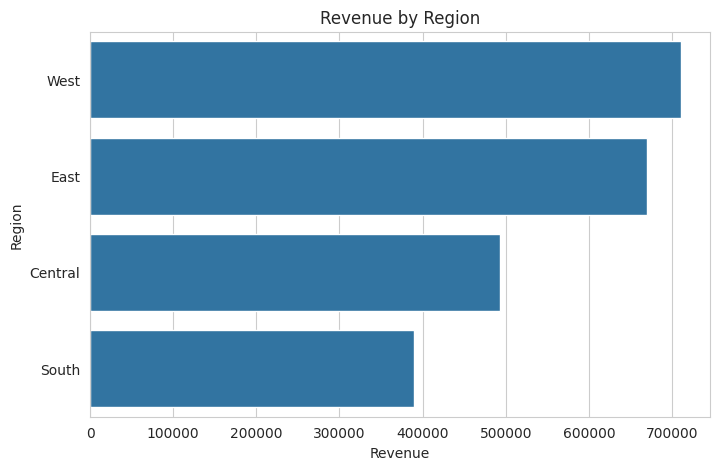

In [18]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index
)

plt.title('Revenue by Region')
plt.xlabel('Revenue')
plt.ylabel('Region')

plt.show()

In [19]:
region_analysis = df.groupby('Region').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique'),
    Customers=('Customer_ID', 'nunique')
).reset_index()

region_analysis['AOV'] = (
    region_analysis['Revenue'] /
    region_analysis['Orders']
)

region_analysis.sort_values(
    'Revenue',
    ascending=False
)

,Region,Revenue,Orders,Customers,AOV
3,West,710219.6845,1587,681,447.523431
1,East,669518.7260,1369,669,489.056776
0,Central,492646.9132,1156,626,426.165150
2,South,389151.4590,810,509,480.433900


In [20]:
category_analysis = df.groupby('Category').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique'),
    Customers=('Customer_ID', 'nunique')
).reset_index()

category_analysis['AOV'] = (
    category_analysis['Revenue'] /
    category_analysis['Orders']
)

category_analysis

,Category,Revenue,Orders,Customers,AOV
0,Furniture,728658.5757,1727,705,421.921584
1,Office Supplies,705422.3340,3676,787,191.899438
2,Technology,827455.8730,1519,684,544.737244


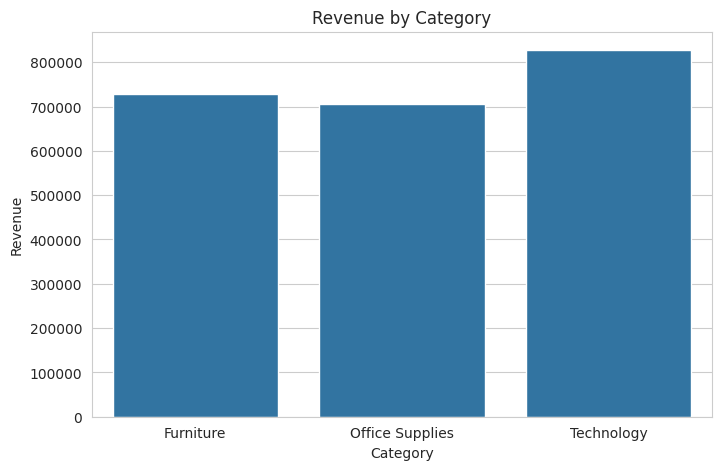

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_analysis,
    x='Category',
    y='Revenue'
)

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

In [22]:
subcategory_analysis = df.groupby('Sub_Category').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique')
).reset_index()

subcategory_analysis['AOV'] = (
    subcategory_analysis['Revenue'] /
    subcategory_analysis['Orders']
)

subcategory_analysis = subcategory_analysis.sort_values(
    'Revenue',
    ascending=False
)

subcategory_analysis

,Sub_Category,Revenue,Orders,AOV
13,Phones,327782.4480,803,408.197320
5,Chairs,322822.7310,566,570.358182
14,Storage,219343.3920,764,287.098681
16,Tables,202810.6280,302,671.558371
3,Binders,200028.7850,1291,154.940964
11,Machines,189238.6310,112,1689.630634
0,Accessories,164186.7000,702,233.884188
6,Copiers,146248.0940,66,2215.880212
4,Bookcases,113813.1987,222,512.672066
1,Appliances,104618.4030,444,235.627034


Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


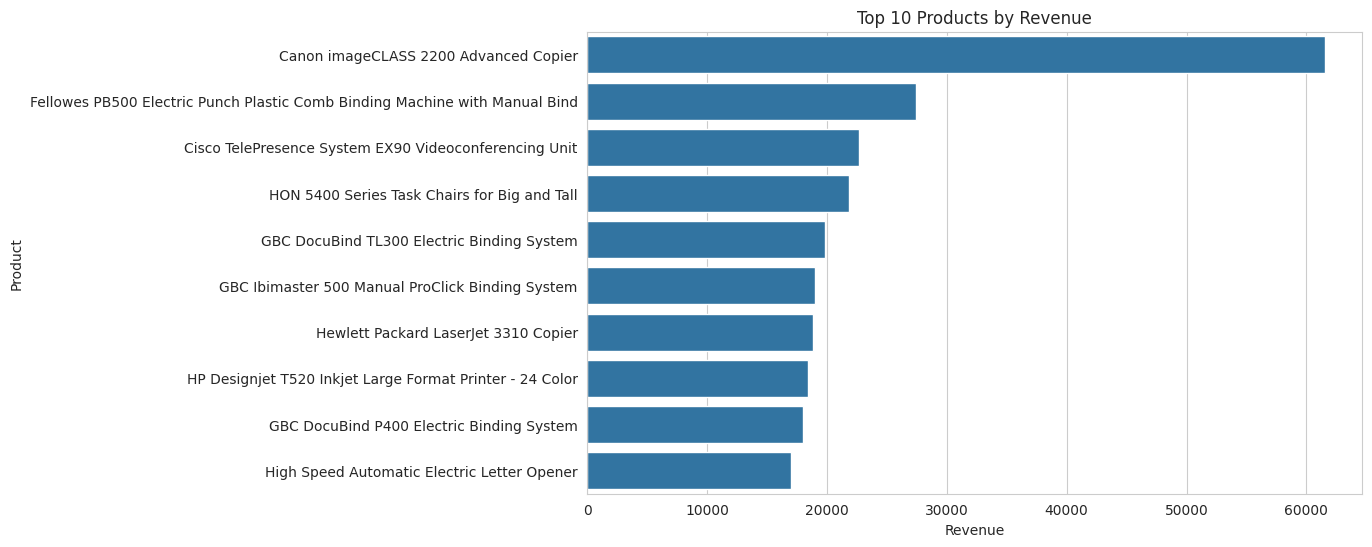

In [23]:
top_products = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

print(top_products)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64


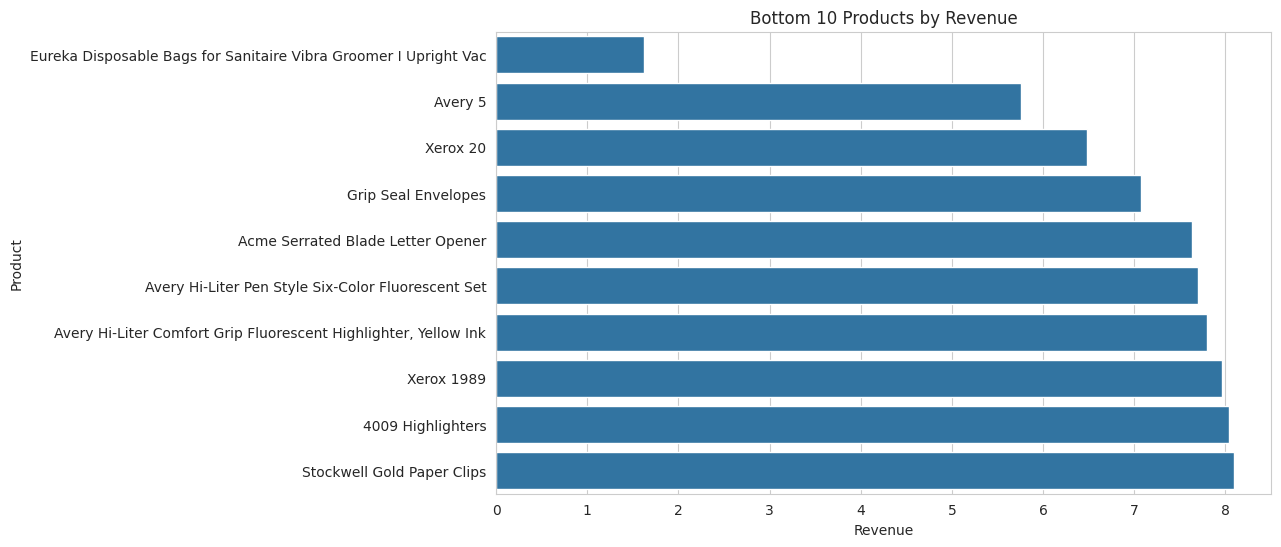

In [24]:
bottom_products = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values().head(10)

print(bottom_products)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=bottom_products.values,
    y=bottom_products.index
)

plt.title('Bottom 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

In [25]:
segment_analysis = df.groupby('Segment').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique'),
    Customers=('Customer_ID', 'nunique')
).reset_index()

segment_analysis['AOV'] = (
    segment_analysis['Revenue'] /
    segment_analysis['Orders']
)

segment_analysis

,Segment,Revenue,Orders,Customers,AOV
0,Consumer,1.148061e+06,2537,409,452.526816
1,Corporate,6.884941e+05,1491,236,461.766650
2,Home Office,4.249822e+05,894,148,475.371563


In [26]:
ship_mode_analysis = df.groupby('Ship_Mode').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique'),
    Average_Shipping_Days=('Shipping_Days', 'mean')
).reset_index()

ship_mode_analysis

,Ship_Mode,Revenue,Orders,Average_Shipping_Days
0,First Class,3.455723e+05,772,2.179214
1,Same Day,1.252190e+05,261,0.044610
2,Second Class,4.499142e+05,944,3.249211
3,Standard Class,1.340831e+06,2945,5.008363


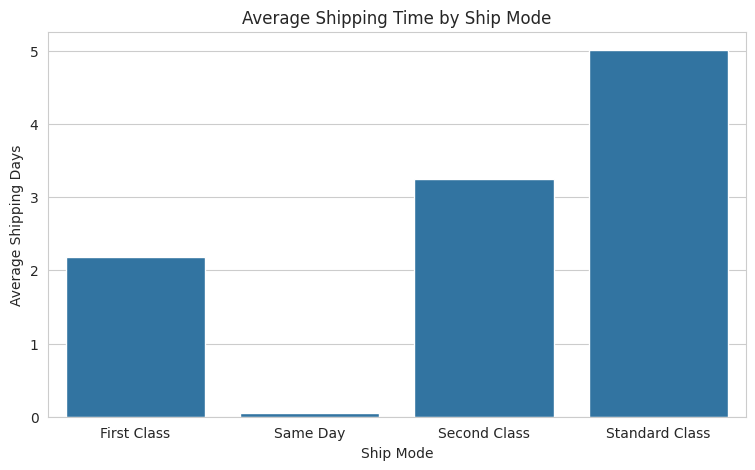

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=ship_mode_analysis,
    x='Ship_Mode',
    y='Average_Shipping_Days'
)

plt.title('Average Shipping Time by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Average Shipping Days')

plt.show()

In [28]:
state_sales = df.groupby(
    'State'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

state_sales

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

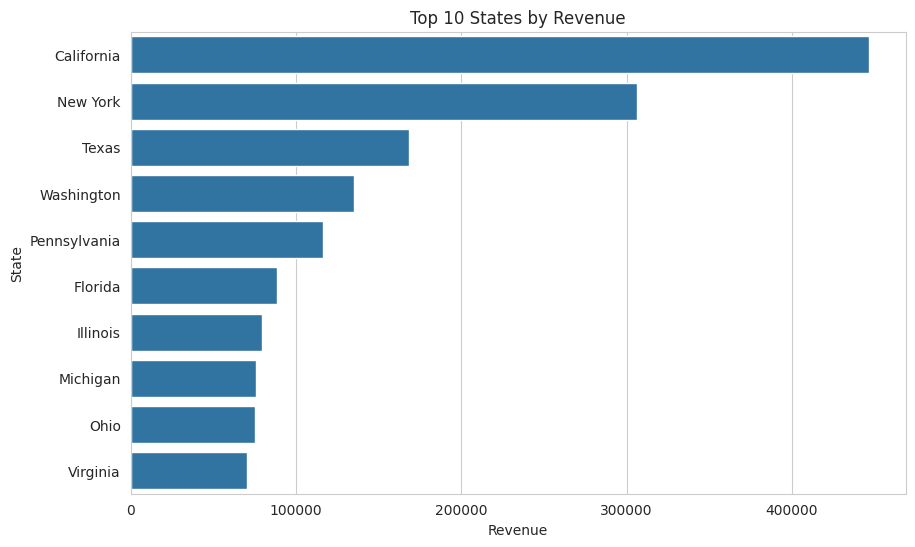

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_sales.values,
    y=state_sales.index
)

plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue')
plt.ylabel('State')

plt.show()

In [30]:
final_region = df.groupby('Region').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique'),
    Customers=('Customer_ID', 'nunique'),
    Average_Shipping_Days=('Shipping_Days', 'mean')
).reset_index()

final_region['AOV'] = (
    final_region['Revenue'] /
    final_region['Orders']
)

final_region.sort_values(
    'Revenue',
    ascending=False
)

,Region,Revenue,Orders,Customers,Average_Shipping_Days,AOV
3,West,710219.6845,1587,681,3.930255,447.523431
1,East,669518.7260,1369,669,3.910233,489.056776
0,Central,492646.9132,1156,626,4.065876,426.165150
2,South,389151.4590,810,509,3.961202,480.433900


In [31]:
highest_region = region_sales.idxmax()
highest_region_revenue = region_sales.max()

lowest_region = region_sales.idxmin()
lowest_region_revenue = region_sales.min()

highest_category = category_analysis.loc[
    category_analysis['Revenue'].idxmax(),
    'Category'
]

highest_subcategory = subcategory_analysis.iloc[0]['Sub_Category']

highest_product = top_products.index[0]

print("Highest Revenue Region:", highest_region)
print("Revenue:", round(highest_region_revenue, 2))

print("\nLowest Revenue Region:", lowest_region)
print("Revenue:", round(lowest_region_revenue, 2))

print("\nHighest Revenue Category:", highest_category)

print("\nHighest Revenue Sub-category:", highest_subcategory)

print("\nTop Product:", highest_product)

print("\nBest Sales Month:", int(best_month['Month']))

print("\nWorst Sales Month:", int(worst_month['Month']))

Highest Revenue Region: West
Revenue: 710219.68

Lowest Revenue Region: South
Revenue: 389151.46

Highest Revenue Category: Technology

Highest Revenue Sub-category: Phones

Top Product: Canon imageCLASS 2200 Advanced Copier

Best Sales Month: 11

Worst Sales Month: 2


## Tactical Recommendations for Alfido Tech

1. **Focus on high-performing regions**
   Allocate more marketing and sales resources to regions generating the highest revenue while identifying opportunities to improve weaker regions.

2. **Prioritize high-performing product categories**
   Increase visibility, inventory and promotional activity for categories contributing the largest share of revenue.

3. **Improve low-performing products**
   Review products with consistently low sales and consider repricing, bundling, improved promotion or removal from the product portfolio.

4. **Use seasonal demand for planning**
   Prepare inventory and marketing campaigns ahead of the months showing historically higher revenue.

5. **Optimize shipping strategy**
   Compare shipping modes based on revenue and average delivery time and encourage customers toward efficient shipping options where appropriate.